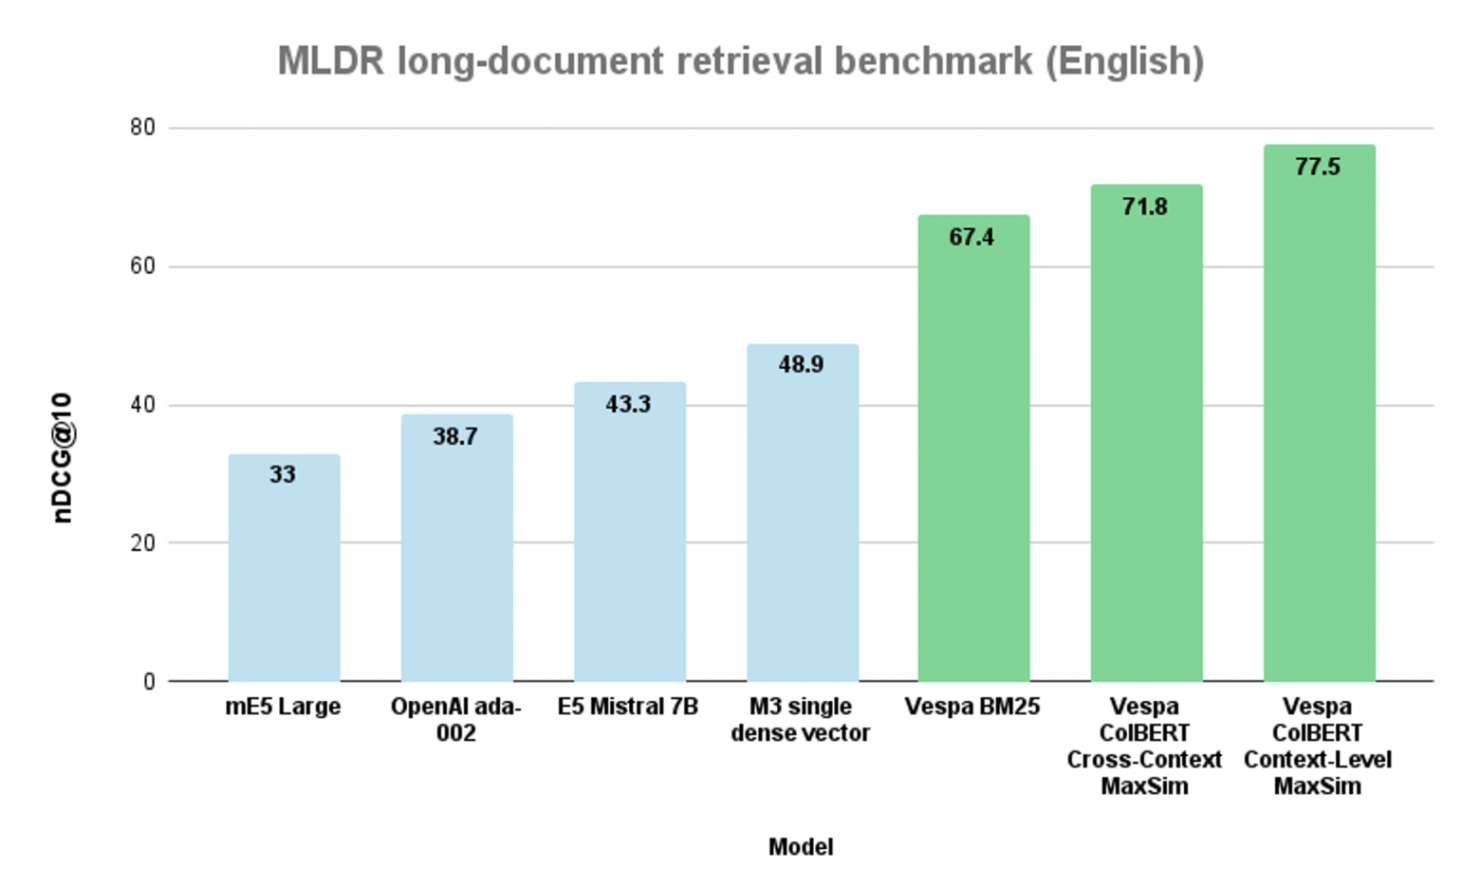
Даже в эпоху поиска с помощью больших языковых моделей, BM25 хорошо держит удар и остается сильным бейзланом. Так же он полезен на практике: он способен дополнять современные системы. Выдачу BM25 можно использовать как один из этапов ранжирования, в том числе отдавая его результаты нейросетям для дальнейшей обработки.

Представим, что нам нужно сделать поиск для интернет магазина. Будем двигаться от самых простых методов, постепенно улучшая их, пока не придем к BM25+.

In [1]:
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
# https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification
data_url = 'https://raw.githubusercontent.com/sugatagh/E-commerce-Text-Classification/main/Dataset/ecommerceDataset.csv'
dataset = pd.read_csv(
    data_url,
    names = ['label', 'description']
)
dataset = dataset.dropna()
dataset = dataset.drop_duplicates()
dataset.head()

,label,description
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


В датасете нас интересует только одна колонка, которая содержит текстовое описание товара: description. Всего у нас таких товаров 27802.

## Глупный, наивный поиск
Самое простое, что мы можем сделать: получив запрос пользователя найти документы, которые целиком его содержат.

In [2]:
print(dataset.shape)
documents = dataset.description.tolist()
def search_dummy(documents, query, limit=10):
    return [doc for doc in documents if query in doc][:limit]

[doc[:100] for doc in search_dummy(documents, 'smartphone', limit=2)]

(27802, 2)


['Shinco 80 cm (32 Inches) HD Ready Smart LED TV SO32AS (Black) (2019 model) Size name:32 Inches   Thi',
 'Amazon Brand - Solimo 12-inch Wall Clock - Checkered (Silent Movement, Black Frame) Bring function a']

Этот метод полон проблем и самая очевидная в том, что такой запрос не вернет ничего: search_dummy(documents, 'SmartphonE', limit=2) .
Необходимо сделать предобработку текстов. Чтобы не особо мудрить, уберем все символы кроме букв и чисел, а так же типичные суффиксы.


In [3]:
search_dummy(documents, 'SmartphonE', limit=2)

[]

Удаление суффиксов можно назвать простым стеммингом: выделением корней. На практике для этого используются более продвинутые методы, например стеммер Портера из пакета nltk. 

In [4]:
import string

def stem(word):
    for suffix in set(['ing', 'ly', 'ed', 'ious', 'ies', 'ive', 'es', 's', 'ment']):
        if word.endswith(suffix):
            return word[:-len(suffix)]
    return word


def preprocess_document(document):
    new_doc = ''.join(
        c for c in document if c.isalnum() or c == ' '
    ).lower().strip()
    new_doc = ' '.join([
        stem(word) for word in new_doc.split(' ')
    ])
    return new_doc

def preprocess_documents(documents):
    new_documents = []
    for doc in documents:
        new_doc = preprocess_document(doc)
        new_documents.append(new_doc)
    return new_documents

documents_preprocessed = preprocess_documents(documents)
documents_preprocessed[:1][0][:50]

'paper plane design fram wall hang motivational off'

In [5]:
def search_dummy(documents, query, limit=10):
    query = preprocess_document(query)
    return [doc for doc in documents if query in doc][:limit]

search_dummy(documents_preprocessed, 'SmartphonE', limit=1)[0][:50]

'shinco 80 cm 32 inche hd ready smart l tv so32a bl'

Отлично, проблема решена. Но любая опечатка в запросе сразу всё ломает, например search_dummy(documents_preprocessed, 'smrtaphone', limit=1) не вернет ничего. Так же не сработают частичные запросы вроде smar, которые часто встречаются в ecommerce.

In [6]:
search_dummy(documents_preprocessed, 'smrtaphone', limit=1)

[]

## Term Frequency на N-граммах
Для решения этих проблем нам помогут N-граммы: разбиение слов в запросе на последовательности символов длиной N.

In [7]:
from nltk.util import ngrams
import nltk

N_GRAM_SIZE = 3

def documents_to_ngrams(documents, n_gram_size=N_GRAM_SIZE, progress=False):
    document_ngrams = []
    iterator = documents
    if progress:
        iterator = tqdm(documents)
    for doc in iterator:
        doc_ngrams = []
        for word in doc.split(' '):
            word_ngrams = ngrams(word, n_gram_size)
            for ngram in word_ngrams:
                doc_ngrams.append(''.join(ngram))
        document_ngrams.append(tuple(doc_ngrams))
    document_ngrams = tuple(document_ngrams)

    return document_ngrams

In [8]:
documents_ngrams = documents_to_ngrams(documents_preprocessed, progress=True)
documents_ngrams[0][:5]

  0%|          | 0/27802 [00:00<?, ?it/s]

('pap', 'ape', 'per', 'pla', 'lan')

Теперь нам уже недостаточно просто выводить всё, что содержит хотя бы одну N-грамму: мы получим много случайных совпадений. Логично выводить первыми те результаты, где совпадений больше всего.
Здесь возникает понятие ранжирования. Нужно не только найти документы, но и отсортировать их в некотором порядке, чтобы наиболее релевантные результаты были сверху. Для этого нужна некая функция ранжирования, которая сопоставляет каждой паре (запрос, документ) число, которое тем больше, чем документ релевантнее запросу пользователя. В данном случае наша функция ранжирования: частота совпадений, или term frequency.

In [9]:
def display_search_results(documents, idx_scores, char_limit=100):
    for idx, score in idx_scores:
        print(f'{score:0.2f}: {documents[idx][:char_limit]}')

def query_to_ngrams(query, n_gram_size=N_GRAM_SIZE):
    return documents_to_ngrams([query], n_gram_size=n_gram_size)[0]

def search_tf(documents_ngrams, query, limit=5, n_gram_size=N_GRAM_SIZE):
    index = [Counter(doc_ngrams) for doc_ngrams in documents_ngrams]
    query = query_to_ngrams(query, n_gram_size)

    match_scores = []
    for ngram_counts in tqdm(index):
        score = 0
        for query_ngram in query:
            score += ngram_counts.get(query_ngram, 0)
        match_scores.append(score)

    idx_scores = zip(range(len(documents_ngrams)), match_scores)
    idx_scores = sorted(idx_scores, key=lambda pair: -pair[1])

    return idx_scores[:limit]

idx_scores = search_tf(documents_ngrams, 'smratphone')
display_search_results(documents, idx_scores)

  0%|          | 0/27802 [00:00<?, ?it/s]

116.00: Risk Savvy: How to Make Good Decisions About the Author GERD GIGERENZER is director of the Max Planc
116.00: Risk Savvy: How to Make Good Decisions About the Author Gerd Gigerenzer is the author of Gut Feeling
105.00: HP B4B09PA Headphones with Mic Product Description HP Headphones Overview With HP B4B09PA Over ear H
98.00: iBall Rocky Over-Ear Headphones with Mic Product Description  iBall Rocky Headset Over-Ear Headphone
96.00: The Global War on Christians: Dispatches from the Front Lines of Anti-Christian Persecution About th


Теперь наш поиск работает при запросах с опечатками, но результат ужасен. Разберемся, что происходит.

**search_tf** осуществляет поиск: принимает на вход N-граммы документов и запрос пользователя, возвращает список кортежей (индекс документа, релевантность), где релевантность это число совпадений N-грамм. Результаты сортируются и функция возвращает только limit наиболее релевантных документов.

Внутри эта функция сначала индексирует документы: считает для каждого, сколько разных N-грамм в нём содержится. Например, в документе "smasmart" содержатся следующие N-граммы: {"sma": 2, "mas": 1, "asm": 1, "mar": 1, "art": 1}. Такой индекс позволяет быстро понять, сколько N-грамм из запроса находится в документе. Строго говоря, его можно было бы посчитать один раз, а не пересчитывать при каждом запросе.

Почему результат такой плохой? Длинные документы содержат больше случайных совпадений и всегда будут выше в выдаче нашего поиска.

Рассмотрим игрушечный пример:

In [11]:
def documents_to_index(documents, n_gram_size=N_GRAM_SIZE):
    documents_preprocessed = [
        preprocess_document(doc) for doc in documents
    ]

    documents_ngrams = documents_to_ngrams(documents_preprocessed, n_gram_size)
    return documents_ngrams

dummy_documents = [
    'smartphone',
    'frying pan',
    'headphones for your smartphone',
]

dummy_documents_ngrams = documents_to_index(dummy_documents)

idx_scores = search_tf(dummy_documents_ngrams, 'smratphone')

display_search_results(dummy_documents, idx_scores)

  0%|          | 0/3 [00:00<?, ?it/s]

7.00: headphones for your smartphone
4.00: smartphone
0.00: frying pan


Чтобы решить проблему, нам бы хотелось сделать так, чтобы N-грамма sma вносила больший вклад в релевантность, если она встречается в документе относительно его длины. Например, в слове smart это одна из трех N-грамм, а в слове smartphone она имеет меньший вес.

In [12]:
def search_tf_weighted(documents_ngrams, query, limit=5, n_gram_size=N_GRAM_SIZE):
    index = [Counter(doc_ngrams) for doc_ngrams in documents_ngrams]
    query = query_to_ngrams(query, n_gram_size)
    match_scores = []
    for ngram_counts in index:
        score = 0
        total_ngrams = sum(ngram_counts.values())
        if total_ngrams == 0:
            continue
        for query_ngram in query:
            score += ngram_counts.get(query_ngram, 0)
        score = score/total_ngrams
        match_scores.append(score)

    idx_scores = zip(range(len(documents_ngrams)), match_scores)
    idx_scores = sorted(idx_scores, key=lambda pair: -pair[1])

    return idx_scores[:limit]

idx_scores = search_tf_weighted(dummy_documents_ngrams, 'smratphone')
display_search_results(dummy_documents, idx_scores)

0.50: smartphone
0.39: headphones for your smartphone
0.00: frying pan


Уже лучше.
Даже поиск по всем документам уже не бесполезен:

In [13]:
idx_scores = search_tf_weighted(documents_ngrams, 'smratphone')
display_search_results(documents, idx_scores)

0.23: Apple iPhone Xs (Space Grey, 4GB RAM, 64GB Storage, 12 MP Dual Camera, 458 PPI Display) Size name:64
0.19: AmazonBasics Lighting to USB A Cable for iPhone and iPad - 4 Inches (10 Centimeters) - Black (Ideal 
0.18: VALUEACTIVE Screen Guard for Samsung Galaxy S10 Plus Tempered Glass Full Screen Coverage 5D Curved F
0.17: TSIM Lifetime Global SIM Card(1GB) Size:1GB   Voice / SMS Slabs 100 minutes/100 SMS in: Australia, B
0.17: JBL T450BT Extra Bass Wireless On-Ear Headphones with Mic (Black) Colour:Black   Colour:Black Powerf


но если добавить прилагательные, то поиск сломается:

In [14]:
idx_scores = search_tf_weighted(documents_ngrams, 'the heavy simple beautiful black iphone')
display_search_results(documents, idx_scores)

0.86: Dick Francis's Refusal Review Praise for Dick Francis’s Refusal “To the delight of Dick/Felix Franci
0.62: Apple iPhone Xs (Space Grey, 4GB RAM, 64GB Storage, 12 MP Dual Camera, 458 PPI Display) Size name:64
0.38: Betting on Horse Racing For Dummies (For Dummies Series) From the Back Cover Cash in big on multiple
0.38: Seagate 2TB Backup Plus Slim (Blue) USB 3.0 External Hard Drive for PC/Mac with 2 Months Free Adobe 
0.36: Introduction to Objectivist Epistemology 


Всё дело в том, что для нашего алгоритма все слова в запросе одинаково важны, что beautiful, что the, что iphone.

## Inverse Document Frequency
Давайте придумаем как можно добавить к каждой N-грамме запроса вес, чтобы он был тем больше, чем она информативнее. Для этого подходит Inverse Document Frequency (IDF): мера того, насколько редко N-грамма встречается среди всех документов. Интуитивно, что чем реже встречается N-грамма, тем больше информации она несет. Например, если the встречается в каждом документе, то эту N-грамму вообще не стоит учитывать при расчете релевантности. И, напротив, если sma встречается в одном документе, то её наличие в запросе позволяет однозначно определить самый релевантный результат.


In [15]:
from collections import defaultdict

def calculate_idf(documents_ngrams):
    ngram_appearance = {}
    for doc_ngrams in documents_ngrams:
        for ngram in set(doc_ngrams):
            if ngram not in ngram_appearance:
                ngram_appearance[ngram] = 0
            ngram_appearance[ngram] += 1
    idf = {}
    N = len(documents_ngrams)
    for ngram, appearance_count in ngram_appearance.items():
        idf[ngram] = np.log((1+N)/(1 + appearance_count))
    return idf

dummy_documents = [
    'smartphone',
    'frying pan',
    'headphones for your smartphone',
]

dummy_documents_ngrams = documents_to_index(dummy_documents)

dummy_idf = calculate_idf(dummy_documents_ngrams)

dummy_idf

{'one': np.float64(0.28768207245178085),
 'art': np.float64(0.28768207245178085),
 'pho': np.float64(0.28768207245178085),
 'mar': np.float64(0.28768207245178085),
 'tph': np.float64(0.28768207245178085),
 'sma': np.float64(0.28768207245178085),
 'hon': np.float64(0.28768207245178085),
 'rtp': np.float64(0.28768207245178085),
 'fry': np.float64(0.6931471805599453),
 'pan': np.float64(0.6931471805599453),
 'hea': np.float64(0.6931471805599453),
 'you': np.float64(0.6931471805599453),
 'our': np.float64(0.6931471805599453),
 'adp': np.float64(0.6931471805599453),
 'for': np.float64(0.6931471805599453),
 'ead': np.float64(0.6931471805599453),
 'dph': np.float64(0.6931471805599453)}

Видно, что N-граммы относящиеся к сковородке получили более высокий вес, так как встречаются реже.

Теперь релевантность документа равна сумме частот N-грамм из запроса помноженных на информативность этих N-грамм.
Она называется TF-IDF:
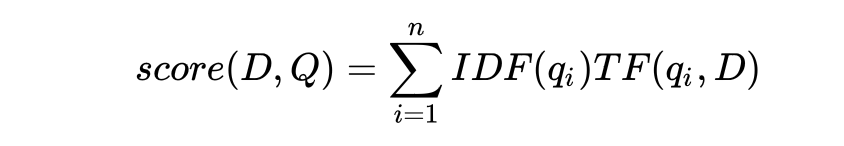
де D это документ, Q это запрос, а q_i это N-грамма из документа. Заметьте, что IDF не зависит от конкретного документа, т.к. рассчитывается по всем документам в нашей коллекции для каждой N-граммы.

N-грамма — это последовательность из n подряд идущих элементов (слов, букв или звуков) из какого-либо текста или данных

In [16]:
def search_tf_idf(
    documents_ngrams,
    query,
    limit=5,
    n_gram_size=N_GRAM_SIZE,
):
    index = [Counter(doc_ngrams) for doc_ngrams in documents_ngrams]
    idf = calculate_idf(documents_ngrams)
    query = query_to_ngrams(query, n_gram_size)

    match_scores = []
    for ngram_counts in tqdm(index):
        score = 0
        total_ngrams = sum(ngram_counts.values())
        if total_ngrams == 0:
            continue
        for query_ngram in query:
            tf_score = ngram_counts.get(query_ngram, 0)/total_ngrams
            idf_score = idf.get(query_ngram, 1e-3)
            score += tf_score * idf_score
        match_scores.append(score)

    idx_scores = zip(range(len(documents_ngrams)), match_scores)
    idx_scores = sorted(idx_scores, key=lambda pair: -pair[1])

    return idx_scores[:limit]

dummy_documents = [
    'smartphone',
    'frying pan',
    'headphones for your smartphone',
]

dummy_documents_ngrams = documents_to_index(dummy_documents)

idx_scores = search_tf_idf(dummy_documents_ngrams, 'smratphone')
display_search_results(dummy_documents, idx_scores)

  0%|          | 0/3 [00:00<?, ?it/s]

0.14: smartphone
0.11: headphones for your smartphone
0.00: frying pan


In [17]:
dummy_documents = [
    'black iphone smartphone 32g protective glass',
    'blue iphone smartphone 32g protective glass',
    'silver navy blue headphones sports wireless small',
    'navy blue pants',
    'red pants',
    'silver necklace',
    'silver mac pro',
    'ihpone 11',
    'black pants',
    'small box',
]

dummy_documents_ngrams = documents_to_index(dummy_documents)


idx_scores = search_tf_idf(dummy_documents_ngrams, 'blue smartphone')
display_search_results(dummy_documents, idx_scores)

  0%|          | 0/10 [00:00<?, ?it/s]

0.62: blue iphone smartphone 32g protective glass
0.50: black iphone smartphone 32g protective glass
0.34: navy blue pants
0.22: silver navy blue headphones sports wireless small
0.20: ihpone 11


In [18]:
idx_scores = search_tf_idf(documents_ngrams, 'health smartwatch')
display_search_results(documents, idx_scores)

  0%|          | 0/27802 [00:00<?, ?it/s]

0.96: A History of American Literature Review "Richard Gray's real achievement is somehow to have compress
0.88: Samsung Gear Sport Smartwatch (Black) Colour:Black   Sports watch design in premium stainless steel 
0.85: American Pastoral Amazon.com Review Philip Roth's 22nd book takes a life-long view of the American e
0.53: M3 Intelligence Bluetooth Health Wrist Smart Band Watch Monitor/Smart Bracelet/Health Bracelet/Activ
0.52: Textbook of Elements of Veterinary Public Health Veterinary Public Health is a multidisciplinary fie


Полноценный поиск работает уже лучше, но всё равно не идеально

## BM25+
На самом деле BM25+ это улучшение TF-IDF с определенным выбором TF и IDF для качественного ранжирования.
Его задумка в том, чтобы сделать такие веса, на которые не будут так сильно влиять длина документов.
Так же он имеет основания из Теории Информации: IDF в BM25+ это по сути собственная информация по Шеннону, то есть сколько информации содержит данная N-грамма.
Помимо этого BM25+ лучше всего работает на словах, а не N-граммах.

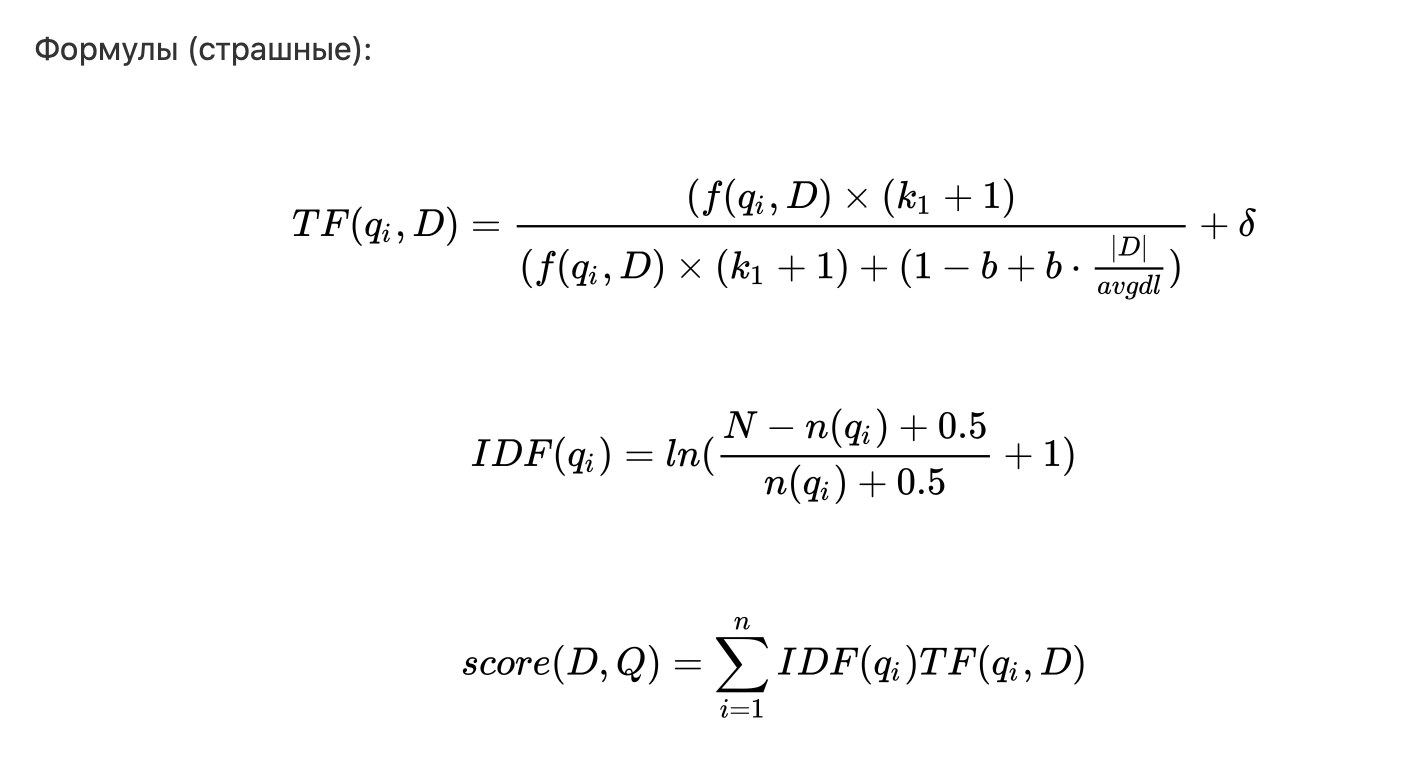

Здесь:
* D - документ.
* Q - запрос.
* f(q_i, D) - число вхождений слова q_i в документ.
* |D| - длина документа.
* avgdl - средняя длина документов в коллекции.
* N - число документов в коллекции.
* n(q_i) - число документов, содержащих слово q_i.
* k_1 - параметр в диапазоне [1.2, 2.0].
* b - параметр, обычно 0.75.
* \delta - параметр, обычно 1.

**По сути TF это вес слова в документе, а IDF это информативность этого слова. Наибольшую релевантность получают документы, в которых много места занимают редкие слова.**

## Реализация BM25+
Осталось только реализовать всё по формулам. В этот раз сделаем всё красиво, обернув код в класс, и не будем пересчитывать индекс при каждом запросе.

In [19]:
def documents_to_words(documents):
    documents_words = tuple([doc.split(' ') for doc in documents])
    documents_words = tuple(documents_words)
    return documents_words

def bm25_documents_to_index(documents):
    documents_preprocessed = [
        preprocess_document(doc) for doc in documents
    ]

    documents_words = documents_to_words(documents_preprocessed)
    return documents_words

def bm25_query_to_wrods(query):
    return bm25_documents_to_index([query])[0]

def idf_bm25(
    number_documents_containing_ngram,
    total_documents,
):
    x = (total_documents - number_documents_containing_ngram + 0.5)/(number_documents_containing_ngram + 0.5)
    return np.log(x + 1)

def tf_bm25(ngram_tf, document_length, average_document_length, k1=1.5, b=0.75, delta=1):
    numerator = ngram_tf*(k1+1)
    denominator = ngram_tf + (k1 * (1 - b + b * document_length/average_document_length))
    return numerator/denominator + delta

def bm25_score(
    ngram_idf,
    ngram_tf,
    document_length,
    average_document_length,
    k1=1.5,
    b=0.75,
):
    numerator = ngram_tf*(k1+1)
    denominator = ngram_tf + (k1 * (1 - b + b * document_length/average_document_length))
    return ngram_idf * tf_bm25(ngram_tf, document_length, average_document_length, k1=k1, b=b)


class SearchBM25:
    def __init__(self):
        self.documents = None
        self.documents_ngrams = None
        self.tf = None
        self.idf = None

    def calculate_tf(self, documents_ngrams):
        tf = [Counter(doc_ngrams) for doc_ngrams in documents_ngrams]

        return tf

    def calculate_idf(self, tf, documents_ngrams):
        idf = {}

        documents_containing = {}

        for doc_tf in tqdm(tf):
            for ngram in doc_tf.keys():
                if not ngram in documents_containing:
                    documents_containing[ngram] = 0
                documents_containing[ngram] += 1

        for ngram in tqdm(documents_containing.keys()):
            idf[ngram] = idf_bm25(
                number_documents_containing_ngram=documents_containing[ngram],
                total_documents=len(documents_ngrams),
            )
        return idf

    def fit(
        self,
        documents,
    ):
        self.documents = documents

        self.documents_ngrams = bm25_documents_to_index(
            documents,
        )

        self.tf = self.calculate_tf(self.documents_ngrams)
        self.idf = self.calculate_idf(self.tf, self.documents_ngrams)

    def search_bm25(
        self,
        query,
        limit,
        only_documents=None,
    ):
        avg_document_length = sum([
            len(doc) for doc in self.documents_ngrams
        ])/len(self.documents_ngrams)
        query = bm25_query_to_wrods(query)
        indexes = []
        match_scores = []

        document_indexes = range(len(self.tf)) if only_documents is None else only_documents
        for i in document_indexes:
            document_tf = self.tf[i]

            document_length = sum(document_tf.values())
            if document_length == 0:
                continue

            score = 0
            for query_ngram in query:
                ngram_score = bm25_score(
                    self.idf.get(query_ngram, 1e-6),
                    document_tf.get(query_ngram, 1e-6),
                    document_length=document_length,
                    average_document_length=avg_document_length,
                )
                score += ngram_score
            match_scores.append(score)
            indexes.append(i)

        idx_scores = zip(indexes, match_scores)
        idx_scores = sorted(idx_scores, key=lambda pair: -pair[1])
        return idx_scores[:limit]


    def search(self, query, limit=5):
        idx_scores = self.search_bm25(
            query,
            limit=limit,
        )
        return idx_scores[:limit]

    def search_and_display(self, query, limit=5, char_limit=100):
        idx_scores = self.search(query, limit=limit)
        display_search_results(self.documents, idx_scores, char_limit=char_limit)

dummy_documents = [
    'black iphone smartphone 32g protective glass',
    'blue iphone smartphone 32g protective glass',
    'silver navy blue headphones sports wireless small',
    'navy blue pants',
    'red pants',
    'silver necklace',
    'silver mac pro',
    'ihpone 11',
    'black pants',
    'small box',
]

index = SearchBM25()
index.fit(dummy_documents)
index.search_and_display('smartphone')

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

2.60: black iphone smartphone 32g protective glass
2.60: blue iphone smartphone 32g protective glass
1.48: red pants
1.48: silver necklace
1.48: ihpone 11


На некоторых запросах поиск работает хорошо, но на других хуже TF-IDF.
BM25+ достаточно чувствителен к правильной предобработке текста. Другая его проблема в том, что в такой реализации он неустойчив к опечаткам и не способен обрабатывать частичные запросы.


In [22]:
index = SearchBM25()
index.fit(documents)

  0%|          | 0/27802 [00:00<?, ?it/s]

  0%|          | 0/106655 [00:00<?, ?it/s]

In [23]:
index.search_and_display('frying')

16.30: Taylor Candy and Deep Fry Stainless Steel Thermometer TAYLOR 5983N Candy/Jelly Deep Fry Thermometer
16.02: Bhavya enterprises Stainless Steel Deep Fat Fryer 8+8 L (Silver) Frying machine used in commercial s
15.96: Hk Villa 2 In 1 Multifuctional Steaming Device egg pan Frying Egg Boiling Roasting Heating Electric 
15.71: HomeFast Multifunction Non-Stick Electric Frying Pan Egg Omelette Pancakes Steak Egg Boiler Electric
15.66: Vishal Smart Mall Multifunction Non-Stick Electric Frying Pan Egg Omelette Pancakes Steak Egg Boiler


## Двухэтапный поиск: TF-IDF + BM25+
Мы можем объединить все преимущества TF-IDF и BM25+. Для этого мы реализуем двухэтапный поиск: сначала TF-IDF на N-граммах будет искать большое число документов-кандидатов, затем BM25+ будет ре-ранжировать эти документы и возвращать лучшие.

In [27]:
from scipy.stats import gmean

class SearchTFIDF:
    def __init__(self, n_gram_size=N_GRAM_SIZE):
        self.n_gram_size = n_gram_size

        self.documents = None
        self.documents_ngrams = None

    def fit(
        self,
        documents,
    ):
        self.documents = documents

        self.documents_ngrams = documents_to_index(
            documents,
            n_gram_size=self.n_gram_size,
        )

    def search(self, query, limit=5):
        idx_scores = search_tf_idf(
            self.documents_ngrams,
            query,
            limit=limit,
            n_gram_size=self.n_gram_size,
        )
        return idx_scores[:limit]

    def search_and_display(self, query, limit=5):
        idx_scores = self.search(query, limit=limit)
        display_search_results(self.documents, idx_scores)

class TwoStageSearch:
    def __init__(self, n_gram_size=3):
        self.n_gram_size = n_gram_size
        self.documents = None
        self.tfidf_index = None
        self.bm25_index = None

    def fit(
        self,
        documents,
    ):
        self.documents = documents

        self.tfidf_index = SearchTFIDF(n_gram_size=self.n_gram_size)
        self.tfidf_index.fit(self.documents)

        self.bm25_index = SearchBM25()
        self.bm25_index.fit(self.documents)

    def search(self, query, limit_stage1=100, limit_stage2=5):
        idx_scores_stage1 = self.tfidf_index.search(query, limit=limit_stage1)
        idx_scores_stage1 = [p for p in idx_scores_stage1 if p[1] > 1e-05]
        idx_to_score_stage1 = {
            idx: score for idx, score in idx_scores_stage1
        }
        only_document_indexes = list(idx_to_score_stage1.keys())
        idx_scores_stage2 = self.bm25_index.search_bm25(query, limit=limit_stage2, only_documents=only_document_indexes)

        aggregated_scores = {
            idx: gmean([score, idx_to_score_stage1[idx]]) for idx, score in idx_scores_stage2
        }
        idx_scores = [(idx, idx_to_score_stage1[idx], score, aggregated_scores[idx]) for idx, score in idx_scores_stage2]

        idx_scores = sorted(idx_scores, key=lambda x: (-round(x[-1],3), -round(x[-2],3), -round(x[-3], 3)))

        return idx_scores

    def display_search_results(self, idx_scores, char_limit=100):
        for idx, score_stage1, score_stage2, score_combined in idx_scores:
            print(f'{score_stage1:0.2f}|{score_stage2:0.2f}|{score_combined:0.2f}: {self.documents[idx][:char_limit]}')

    def search_and_display(self, query, limit_stage1=100, limit_stage2=5, char_limit=100):
        idx_scores = self.search(query, limit_stage1=limit_stage1, limit_stage2=limit_stage2)
        self.display_search_results(idx_scores, char_limit=char_limit)



логика простая:

1. Строим индексы для TF-IDF и BM25+
2. При поступлении запроса сначала запускаем TF-IDF и получаем 100 самых релевантных результата.
3. Запускаем BM25+ на этих результатах и получаем 5 самых релевантных.
4. Чтобы отсортировать результаты мы усредняем оценки полученные от TF-IDF и BM25+ геометрическим средним (в отличие от арифметического оно устойчиво к тому, что оценки могут находится на разных шкалах).
5. Сортируем результаты по усредненным оценкам. При ничьей сортируем по оценка от TF-IDF.


In [28]:
index = TwoStageSearch()
index.fit(documents)
index.search_and_display('iph')

  0%|          | 0/27802 [00:00<?, ?it/s]

  0%|          | 0/106655 [00:00<?, ?it/s]

  0%|          | 0/27802 [00:00<?, ?it/s]

0.12|0.00|0.00: Apple iPhone 8 (Space Grey, 2GB RAM, 64GB Storage)
0.09|0.00|0.00: Natation 3D VR Box Virtual Reality Glasses (VR_Headset) (VR Basic)
0.08|0.00|0.00: Tidy Up! Wire Bin (Black)
0.06|0.00|0.00: Orion Premium Telescope Accessory Kit - 1.25" Orion Orion 08890 1.25-Inch Premium Telescope Accessor
0.04|0.00|0.00: Apple iPhone 6S (Rose Gold, 2GB RAM, 32GB Storage)


Теперь наш поиск успешно обрабатывает частичные запросы, устойчив к опечаткам и выдает небесполезные результаты. Конечно, до настоящего поиска в продакшне ему ещё далеко.